# Prepare SimBench 2016 Prosumer Data

Build the full-year SimBench prosumer CSV, then export quarterly segmented
train/test splits with warmup rows for forecast evaluation.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root


WindowsPath('D:/GithubProject/MADRL_ESS')

In [3]:
from data.loaders.simbench_export import export_simbench_2016_dataset

price_candidates = [
    project_root / "data" / "raw" / "Germany_price_15_2016.xlsx",
    project_root / "data" /"raw" /  "Germany_price_15_2016.csv",
]
price_path = next((path for path in price_candidates if path.exists()), None)
if price_path is None:
    raise FileNotFoundError(f"Missing Germany price source. Checked: {price_candidates}")

export_result, prosumer_rank_df = export_simbench_2016_dataset(
    output_dir=project_root / "data",
    price_path=price_path,
)

simbench_full_df = export_result.full_frame
simbench_train_df = export_result.train_frame
simbench_test_df = export_result.test_frame
metadata_payload = export_result.metadata

summary = {
    "price_path": str(price_path),
    "full_rows": len(simbench_full_df),
    "train_rows": len(simbench_train_df),
    "test_rows": len(simbench_test_df),
    "train_segments": metadata_payload["train_segments"],
    "test_segments": metadata_payload["test_segments"],
    "test_target_rows": metadata_payload["test_target_rows"],
    "test_warmup_rows": metadata_payload["test_warmup_rows"],
}
summary


d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\sim

{'price_path': 'D:\\GithubProject\\MADRL_ESS\\data\\raw\\Germany_price_15_2016.xlsx',
 'full_rows': 35136,
 'train_rows': 27072,
 'test_rows': 8064,
 'train_segments': 5,
 'test_segments': 4,
 'test_target_rows': 5376,
 'test_warmup_rows': 2688}

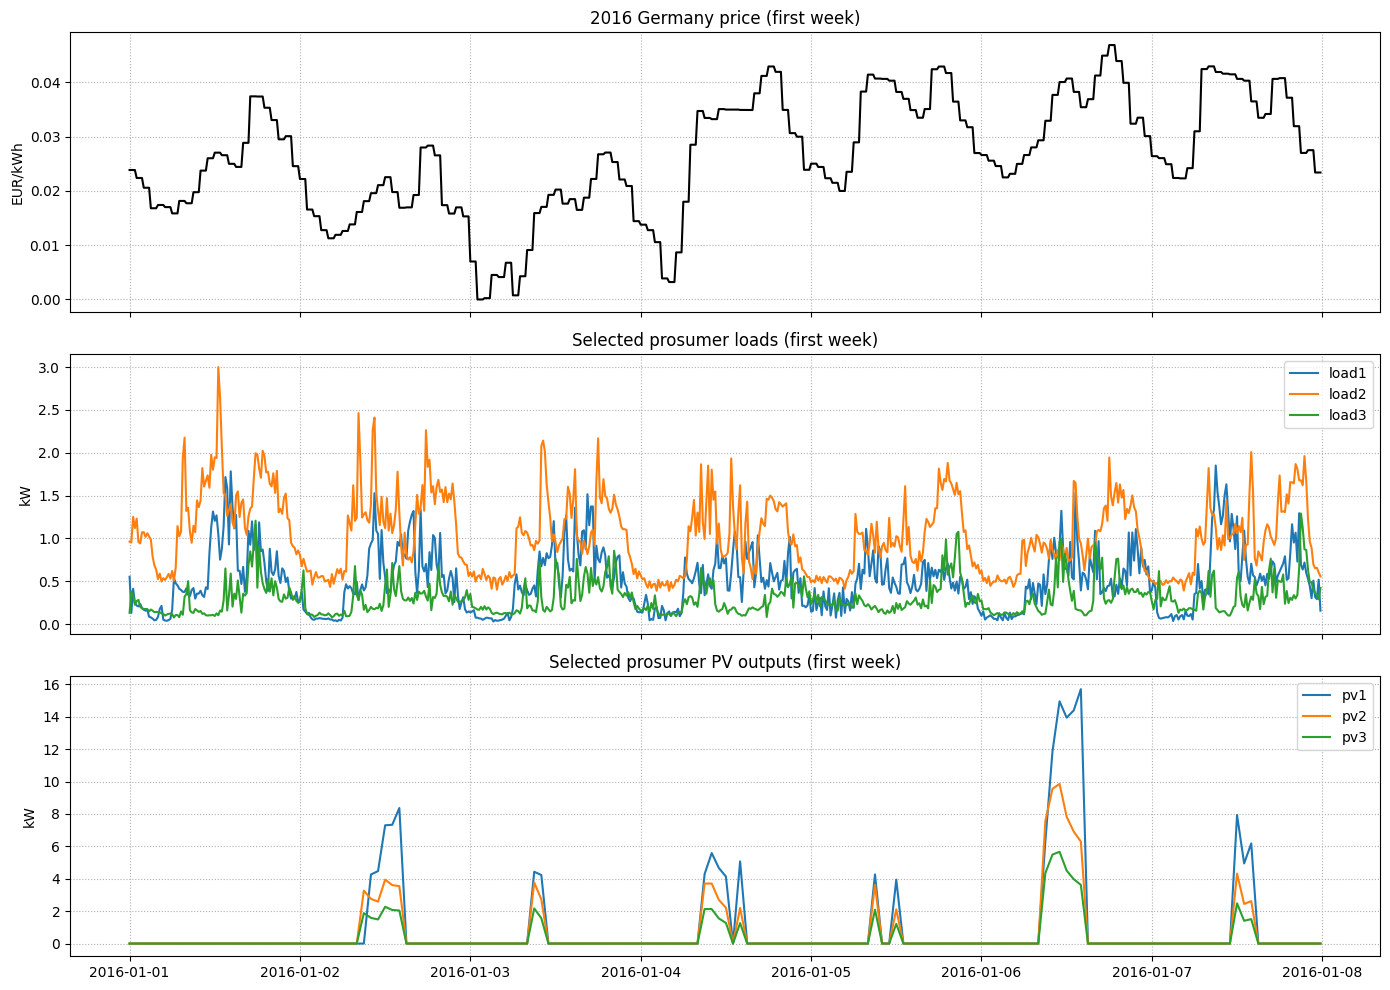

,quarter,segment_id,warmup_start,warmup_end,test_start,test_end,warmup_rows,test_rows
0,1,0,2016-02-01 00:00:00,2016-02-07 23:45:00,2016-02-08 00:00:00,2016-02-21 23:45:00,672,1344
1,2,1,2016-05-02 00:00:00,2016-05-08 23:45:00,2016-05-09 00:00:00,2016-05-22 23:45:00,672,1344
2,3,2,2016-08-01 00:00:00,2016-08-07 23:45:00,2016-08-08 00:00:00,2016-08-21 23:45:00,672,1344
3,4,3,2016-10-31 00:00:00,2016-11-06 23:45:00,2016-11-07 00:00:00,2016-11-20 23:45:00,672,1344


,bus_id,pv_peak_kw,load_peak_kw,pv_energy_index
0,10,46.102448,2.0,195072.984375
1,6,24.105246,3.0,108152.523438
2,12,13.860517,2.0,62187.703125
3,7,11.310618,3.0,50902.703125


,timestamp,price,load1,pv1,load2,pv2,load3,pv3,split_role,is_warmup,segment_id,week_id,quarter
0,2016-01-01 00:00:00,0.02386,0.553370,0.0,0.963159,0.0,0.131652,0.0,train,False,0,-1,0
1,2016-01-01 00:15:00,0.02386,0.132022,0.0,0.952632,0.0,0.380952,0.0,train,False,0,-1,0
2,2016-01-01 00:30:00,0.02386,0.412922,0.0,1.252632,0.0,0.336134,0.0,train,False,0,-1,0
3,2016-01-01 00:45:00,0.02386,0.255618,0.0,1.121052,0.0,0.226890,0.0,train,False,0,-1,0
4,2016-01-01 01:00:00,0.02239,0.216292,0.0,1.231578,0.0,0.268908,0.0,train,False,0,-1,0


,timestamp,price,load1,pv1,load2,pv2,load3,pv3,split_role,is_warmup,segment_id,week_id,quarter
0,2016-02-01 00:00:00,0.01631,0.258426,0.0,0.708000,0.0,0.112044,0.0,test_warmup,True,0,0,1
1,2016-02-01 00:15:00,0.01631,0.415730,0.0,0.518526,0.0,0.106442,0.0,test_warmup,True,0,0,1
2,2016-02-01 00:30:00,0.01631,0.278090,0.0,0.552633,0.0,0.148460,0.0,test_warmup,True,0,0,1
3,2016-02-01 00:45:00,0.01631,0.207866,0.0,0.423789,0.0,0.142858,0.0,test_warmup,True,0,0,1
4,2016-02-01 01:00:00,0.01442,0.221910,0.0,0.431580,0.0,0.086834,0.0,test_warmup,True,0,0,1


In [4]:
plot_steps = 96 * 7
plot_df = simbench_full_df.iloc[:plot_steps].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(plot_df["timestamp"], plot_df["price"], label="price", color="black")
axes[0].set_ylabel("EUR/kWh")
axes[0].set_title("2016 Germany price (first week)")
axes[0].grid(True, linestyle=":")

for agent_idx in range(1, 4):
    axes[1].plot(plot_df["timestamp"], plot_df[f"load{agent_idx}"], label=f"load{agent_idx}")
axes[1].set_ylabel("kW")
axes[1].set_title("Selected prosumer loads (first week)")
axes[1].grid(True, linestyle=":")
axes[1].legend(loc="upper right")

for agent_idx in range(1, 4):
    axes[2].plot(plot_df["timestamp"], plot_df[f"pv{agent_idx}"], label=f"pv{agent_idx}")
axes[2].set_ylabel("kW")
axes[2].set_title("Selected prosumer PV outputs (first week)")
axes[2].grid(True, linestyle=":")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

display(pd.DataFrame(metadata_payload["quarter_test_windows"]))
display(prosumer_rank_df.head(10))
display(simbench_train_df.head())
display(simbench_test_df.head())
